In [ ]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


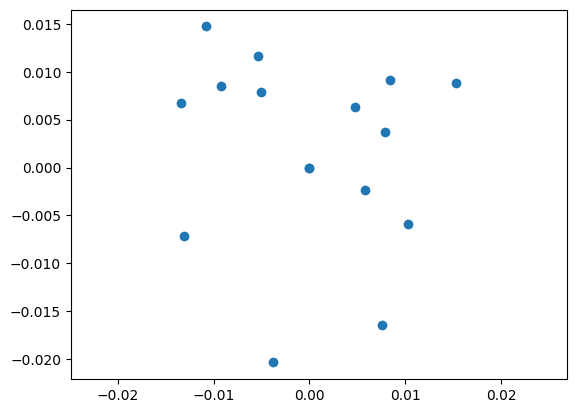

In [36]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=16,  # 轨迹的控制点数量 16
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.01
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.01

plt.scatter(xs, ys)
plt.axis('equal')
pass

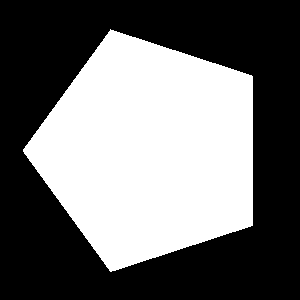

In [ ]:
# 可视化墙（白色区域为墙）

import math
from utils import test_forbidden_function

normal_0 = ti.Vector([1., 0.])
normal_1 = ti.Vector([math.cos(math.pi * 2 / 5), math.sin(math.pi * 2 / 5)])
normal_2 = ti.Vector([math.cos(math.pi * 4 / 5), math.sin(math.pi * 4 / 5)])
normal_3 = ti.Vector([math.cos(math.pi * 6 / 5), math.sin(math.pi * 6 / 5)])
normal_4 = ti.Vector([math.cos(math.pi * 8 / 5), math.sin(math.pi * 8 / 5)])
edge_distance = 0.5 / math.tan(math.pi / 5)  # 单位边长的正五边形的内切圆半径
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return ti.math.dot(v, normal_0) < edge_distance and ti.math.dot(v, normal_1) < edge_distance and ti.math.dot(v, normal_2) < edge_distance and ti.math.dot(v, normal_3) < edge_distance and ti.math.dot(v, normal_4) < edge_distance

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [70]:
xs, ys, rotations = np.load('../trajectory/能让正五边形旋转一周的房间_0/sofa_600.npy')

(np.float64(-0.039537752704253824),
 np.float64(0.039126855768612745),
 np.float64(-0.040231726452366695),
 np.float64(0.03708595928278773))

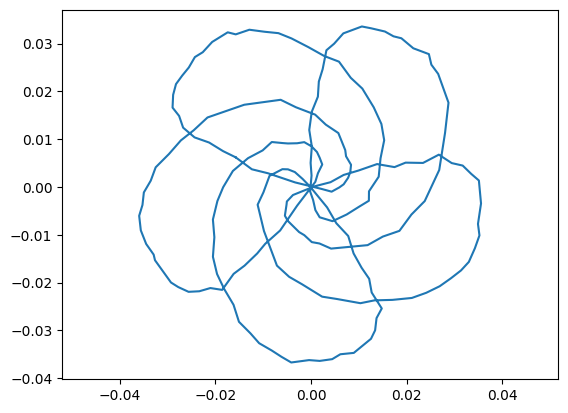

In [79]:
plt.plot(xs, ys)
plt.axis('equal')

In [5]:
sofa_w, sofa_h = 2, 2   # 求解域的尺寸

initial area = 1.7299998998641968, initial loss = -1.7299998998641968
iter 500 / 10000, maximal_area = 1.7300127744674683, loss = -1.7300127744674683
iter 1000 / 10000, maximal_area = 1.7300150394439697, loss = -1.7300150394439697
iter 1500 / 10000, maximal_area = 1.730023980140686, loss = -1.730023980140686
iter 2000 / 10000, maximal_area = 1.7300443649291992, loss = -1.7300443649291992
iter 2500 / 10000, maximal_area = 1.7300541400909424, loss = -1.7300541400909424
iter 3000 / 10000, maximal_area = 1.730075478553772, loss = -1.730075478553772
Adjusted mutation rate, mutation_sigma_pos = 0.0033000000000000004, mutation_sigma_rotation = 0.0
iter 3500 / 10000, maximal_area = 1.7300844192504883, loss = -1.7300844192504883
iter 4000 / 10000, maximal_area = 1.7300901412963867, loss = -1.7300901412963867
Adjusted mutation rate, mutation_sigma_pos = 0.0029700000000000004, mutation_sigma_rotation = 0.0
iter 4500 / 10000, maximal_area = 1.7300986051559448, loss = -1.7300986051559448
iter 5000 

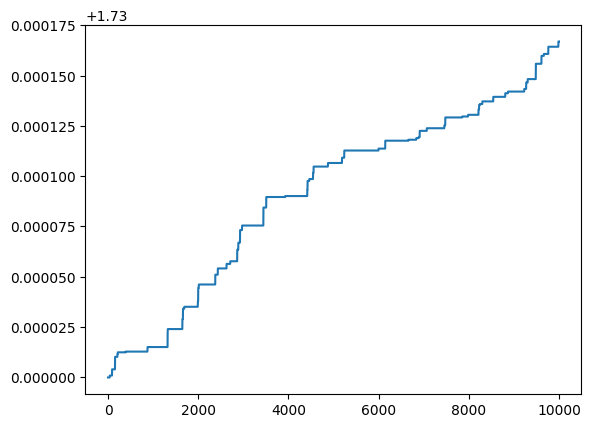

In [76]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    ys,
    rotations,
    # initial_xs=zoom(xs, zoom=(2 * len(xs) - 1) / len(xs), order=1),  # 保持轨迹分辨率时注释掉这三行
    # initial_ys=zoom(ys, zoom=(2 * len(ys) - 1) / len(ys), order=1),
    # initial_rotations=zoom(rotations, zoom=(2 * len(rotations) - 1) / len(rotations), order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    iterations = 10000,  # 10000
    auto_divide_trajectory=True,
    mutation_sigma_pos = 0.003,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    auto_adjust_mutation_rate=True,
    trajectory_upsampling=21,  # 41 101
    resolution=3000,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让正五边形旋转一周的房间_0/sofa_',
    save_image_start_id=700,  # 文件起始标号
    save_trajectory_path='../trajectory/能让正五边形旋转一周的房间_0/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [78]:
len(xs)

233

In [80]:
from utils import get_area

best_score = get_area(is_forbidden, xs, ys, rotations, sofa_w, sofa_h, resolution=5000, trajectory_upsampling=200)  # 以很高的分辨率计算面积

area = sofa_w * sofa_h - best_score  # 房间面积
area_disk = np.pi * (0.5 / math.sin(math.pi / 5)) ** 2  # 圆的面积
area / area_disk
print(f'相对于外接圆：{area} / {area_disk} = {area / area_disk}')

相对于外接圆：2.270605444908142 / 2.2732777998989686 = 0.9988244485601604
